# Brouillon - Modèle 1 (exploration)

Ce notebook n'est **pas** le rendu. C'est la trace de travail, on y teste librement les pistes, y compris
celles qu'on écarte. Le rendu propre est dans `Projet_modele1.ipynb`.

In [41]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt

In [42]:
data = np.loadtxt('virus4.csv', delimiter=',')
V = data[:, 0]
P = data[:, 1]
N = len(data)

## Pas de temps

L'equation des predateurs n'a pas de bruit. On en tire dt en chaque point, on prend la valeur typique.

In [43]:
num = P[1:] - P[:-1]
den = P[:-1] * (V[:-1] - 1)
ok = np.abs(den) > 1e-3
dt_tous = num[ok] / den[ok]
dt = round(np.median(dt_tous), 3)
tau = N * dt
print('dt median =', np.median(dt_tous), ' ecart-type =', np.std(dt_tous))
print('dt retenu =', dt, ' tau =', tau)

dt median = 0.014996020434087135  ecart-type = 0.0002542680276979465
dt retenu = 0.015  tau = 30.0


## Extraction de X et verification

On extrait X, puis on verifie en le reinjectant dans Euler. Si l'erreur est nulle, l'extraction est exacte
et les donnees viennent bien d'un schema d'Euler.

In [44]:
X = (V[1:] - V[:-1]) / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]

Vrec = np.zeros(N)
Vrec[0] = V[0]
for k in range(N - 1):
    Vrec[k+1] = Vrec[k] + Vrec[k] * (2/3 - 4/3 * P[k] + X[k]) * dt
print('erreur de reconstruction :', np.max(np.abs(Vrec - V)))

erreur de reconstruction : 0.0


## Observation de X

On regarde sa moyenne, son ecart-type, sa plage, sa regularite (autocorrelation a lag 1) et son lien avec P.

In [45]:
print('moyenne =', np.mean(X), ' ecart-type =', np.std(X, ddof=1))
print('plage : [%.3f, %.3f]' % (X.min(), X.max()))
print('autocorr lag 1 :', np.corrcoef(X[:-1], X[1:])[0, 1])
print('correlation avec P :', np.corrcoef(X, P[:-1])[0, 1])

moyenne = -0.3951685441095698  ecart-type = 0.227989588243994
plage : [-0.707, -0.000]
autocorr lag 1 : 0.9996082133676376
correlation avec P : 0.9608222502259164


X est tres regulier (autocorr proche de 1), reste negatif, et suit P. Ce n'est pas un bruit blanc.

## Piste 1 : Ornstein-Uhlenbeck stationnaire N(0,1)

Le candidat le plus simple du cours. On teste si la marginale de X est une N(0,1).

In [46]:
p_std = scs.ks_1samp(X, scs.norm(0, 1).cdf).pvalue
p_ajuste = scs.ks_1samp(X, scs.norm(np.mean(X), np.std(X, ddof=1)).cdf).pvalue
print('KS vs N(0,1)       :', p_std)
print('KS vs N ajustee    :', p_ajuste)
print('=> rejete, X n est pas une N(0,1) ni meme une normale')

KS vs N(0,1)       : 0.0
KS vs N ajustee    : 3.0098545087342485e-87
=> rejete, X n est pas une N(0,1) ni meme une normale


## Piste 2 : Ornstein-Uhlenbeck general

On ajuste un OU a moyenne non nulle par AR(1). On teste si les residus sont gaussiens et sans memoire.

In [47]:
x0 = X[:-1]; x1 = X[1:]
rho = np.cov(x0, x1, ddof=1)[0, 1] / np.var(x0, ddof=1)
m = (np.mean(x1) - rho * np.mean(x0)) / (1 - rho)
eps = x1 - (m + rho * (x0 - m))
gamma = -np.log(rho) / dt
s = np.std(eps, ddof=1) / np.sqrt((1 - rho**2) / (2 * gamma))
print('gamma =', gamma, ' m =', m, ' s =', s)
print('residus : KS normalite =', scs.ks_1samp(eps, scs.norm(0, np.std(eps, ddof=1)).cdf).pvalue)
print('residus : autocorr lag1 =', np.corrcoef(eps[:-1], eps[1:])[0, 1])
print('=> capture la tendance mais residus non gaussiens et un peu correles')

gamma = 0.069276521888007  m = -0.6565149939412765  s = 0.052104393128062365
residus : KS normalite = 2.732409397794702e-14
residus : autocorr lag1 = 0.25729177556246746
=> capture la tendance mais residus non gaussiens et un peu correles


## Piste 3 : mouvement brownien integral

Si X etait l'integrale d'un brownien, sa derivee serait un brownien. On teste la derivee discrete.

In [48]:
D = (X[1:] - X[:-1]) / dt          # derivee discrete de X
dD = D[1:] - D[:-1]                 # increments de la derivee
print('increments de la derivee : KS normalite =', scs.ks_1samp(dD, scs.norm(0, np.std(dD, ddof=1)).cdf).pvalue)
print('increments de la derivee : autocorr lag1 =', np.corrcoef(dD[:-1], dD[1:])[0, 1])
print('=> rejete, la derivee n est pas un brownien')

increments de la derivee : KS normalite = 6.312140202275475e-07
increments de la derivee : autocorr lag1 = -0.3141052361905855
=> rejete, la derivee n est pas un brownien


## Test chiffre du modele OU sur X (Monte-Carlo)

On verifie si les statistiques de X tombent dans la masse des simulations OU.

In [49]:
def ou_path(rng):
    o = np.zeros(len(X)); o[0] = X[0]
    sig = np.std(eps, ddof=1)
    for k in range(1, len(X)):
        o[k] = m + rho * (o[k-1] - m) + sig * rng.standard_normal()
    return o

def stats(x):
    return {'amplitude': np.max(np.abs(x)),
            'variance': np.var(x, ddof=1),
            'autocorr lag1': np.corrcoef(x[:-1], x[1:])[0, 1],
            'autocorr lag50': np.corrcoef(x[:-50], x[50:])[0, 1]}

rng = np.random.default_rng(0)
sd = stats(X)
S = {k: [] for k in sd}
for _ in range(500):
    so = stats(ou_path(rng))
    for k in so:
        S[k].append(so[k])
for k in sd:
    arr = np.array(S[k])
    p = 2 * min(np.mean(arr >= sd[k]), np.mean(arr <= sd[k]))
    print('%-15s reel=%.4f  [5%%,95%%]=[%.4f, %.4f]  p=%.3f' % (k, sd[k], np.percentile(arr,5), np.percentile(arr,95), p))

# le test fin sur les increments echoue : X n'est pas exactement un OU
o = ou_path(np.random.default_rng(1))
print('\nKS increments (donnees vs OU) : p=%.3f  -> distribution fine non gaussienne' % scs.ks_2samp(np.diff(X), np.diff(o)).pvalue)

amplitude       reel=0.7067  [5%,95%]=[0.4493, 0.8684]  p=0.740
variance        reel=0.0520  [5%,95%]=[0.0105, 0.0637]  p=0.268
autocorr lag1   reel=0.9996  [5%,95%]=[0.9981, 0.9997]  p=0.280
autocorr lag50  reel=0.9796  [5%,95%]=[0.9027, 0.9855]  p=0.380

KS increments (donnees vs OU) : p=0.000  -> distribution fine non gaussienne


## Validation robuste de la piste 2 (OU)

Au lieu de tester la serie bruitee, on simule le systeme couple complet avec X = OU et on compare aux donnees.

In [51]:
def simule_systeme(gamma, m, s, graine=None):
    rng = np.random.default_rng(graine)
    Vs = np.zeros(N); Ps = np.zeros(N); Xs = np.zeros(N)
    Vs[0], Ps[0], Xs[0] = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(N - 1):
        Xs[k+1] = m + r * (Xs[k] - m) + e * rng.standard_normal()
        Vs[k+1] = Vs[k] + Vs[k] * (2/3 - 4/3 * Ps[k] + Xs[k]) * dt
        Ps[k+1] = Ps[k] + Ps[k] * (-1 + Vs[k]) * dt
    return Vs, Ps, Xs

donnees : V[0.70, 1.31]  P fin = 0.0720
sim 0   : V[0.52, 1.17]  P fin = 0.0078
sim 1   : V[0.58, 1.13]  P fin = 0.0008
sim 2   : V[0.09, 1.24]  P fin = 0.0001


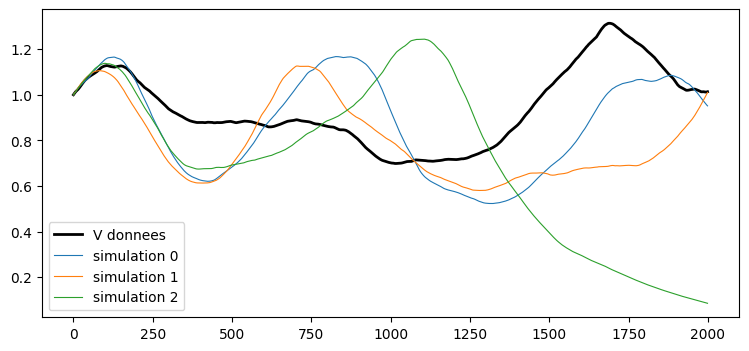

In [52]:
print('donnees : V[%.2f, %.2f]  P fin = %.4f' % (V.min(), V.max(), P[-1]))
for g in range(3):
    Vs, Ps, Xs = simule_systeme(gamma, m, s, graine=g)
    print('sim %d   : V[%.2f, %.2f]  P fin = %.4f' % (g, Vs.min(), Vs.max(), Ps[-1]))

plt.figure(figsize=(9, 4))
plt.plot(V, 'k', linewidth=2, label='V donnees')
for g in range(3):
    Vs, Ps, Xs = simule_systeme(gamma, m, s, graine=g)
    plt.plot(Vs, linewidth=0.8, label='simulation %d' % g)
plt.legend()
plt.show()

## Bilan du brouillon

- dt = 0.015, tau = 30, extraction de X exacte.
- Pistes ecartees : OU stationnaire N(0,1), mouvement brownien integral.
- Piste retenue : OU general, gamma ~ 0.07, m ~ -0.66, s ~ 0.05. Imparfait (residus), mais c'est le
  meilleur candidat simple du cours. Validation par simulation correcte qualitativement, un peu trop
  severe sur les predateurs.
- A reprendre au propre dans le rendu, en ne gardant que ce qu'on decide de presenter.

# Q1.2 - Probabilité d'extinction (exploration)

Extinction au premier instant ou $V_t \le 0.01$ ou $P_t \le 0.01$. C'est un temps d'arret.
On simule beaucoup de trajectoires avec le modele OU de la Q1.1.

In [53]:
def simule(rng, n):
    # simule (V, P) avec X un OU, sur n pas
    Vs = np.zeros(n); Ps = np.zeros(n); Xs = np.zeros(n)
    Vs[0], Ps[0], Xs[0] = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(n - 1):
        Xs[k+1] = m + r * (Xs[k] - m) + e * rng.standard_normal()
        Vs[k+1] = Vs[k] + Vs[k] * (2/3 - 4/3 * Ps[k] + Xs[k]) * dt
        Ps[k+1] = Ps[k] + Ps[k] * (-1 + Vs[k]) * dt
    return Vs, Ps

## Probabilites d'extinction sur la fenetre [0, tau]

In [54]:
seuil = 0.01
M = 2000
rng = np.random.default_rng(0)
nb_V = 0; nb_P = 0
for i in range(M):
    Vs, Ps = simule(rng, N)
    if np.any(Vs <= seuil): nb_V += 1
    if np.any(Ps <= seuil): nb_P += 1
print('P(extinction victimes)   =', nb_V / M)
print('P(extinction predateurs) =', nb_P / M)

P(extinction victimes)   = 0.0015
P(extinction predateurs) = 0.3415


Les victimes ne s'eteignent presque jamais (elles oscillent autour de 1). Les predateurs declinent,
ce sont eux le vrai risque. Pour proposer une loi du temps d'extinction des predateurs, on simule sur un
horizon plus long que tau, sinon la fenetre coupe la distribution.

In [55]:
def temps_extinction_P(rng, n):
    # renvoie le temps ou P passe sous le seuil, -1 sinon
    Vk, Pk, Xk = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(1, n):
        Xk = m + r * (Xk - m) + e * rng.standard_normal()
        Vk = Vk + Vk * (2/3 - 4/3 * Pk + Xk) * dt
        Pk = Pk + Pk * (-1 + Vk) * dt
        if Pk <= seuil:
            return k * dt
    return -1

horizon = 120
n = int(horizon / dt)
rng = np.random.default_rng(7)
T = []
for i in range(1000):
    t = temps_extinction_P(rng, n)
    if t > 0:
        T.append(t)
T = np.array(T)
print('nb extinctions =', len(T), ' moyenne =', T.mean(), ' ecart-type =', T.std())
print('P(extinction avant tau=30) =', np.mean(T <= 30))

nb extinctions = 1000  moyenne = 39.36949499999999  ecart-type = 17.04445094803511
P(extinction avant tau=30) = 0.335


## On teste plusieurs lois candidates

In [56]:
for nom, loi in [('gamma', scs.gamma), ('weibull_min', scs.weibull_min), ('lognorm', scs.lognorm)]:
    par = loi.fit(T)
    p = scs.kstest(T, loi.cdf, args=par).pvalue
    print('%-12s KS p-value = %.4f' % (nom, p))

gamma        KS p-value = 0.4130
weibull_min  KS p-value = 0.0216
lognorm      KS p-value = 0.2214


La loi gamma n'est pas rejetee (p autour de 0.4). On la retient.

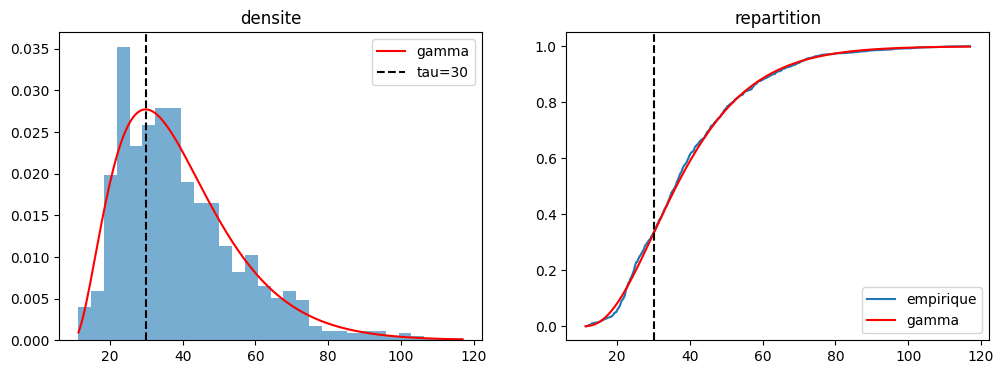

In [57]:
par = scs.gamma.fit(T)
xx = np.linspace(T.min(), T.max(), 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(T, bins=30, density=True, alpha=0.6)
ax[0].plot(xx, scs.gamma.pdf(xx, *par), 'r', label='gamma')
ax[0].axvline(30, color='k', linestyle='--', label='tau=30')
ax[0].legend(); ax[0].set_title('densite')
Ts = np.sort(T); F = np.arange(1, len(Ts)+1) / len(Ts)
ax[1].plot(Ts, F, label='empirique')
ax[1].plot(xx, scs.gamma.cdf(xx, *par), 'r', label='gamma')
ax[1].axvline(30, color='k', linestyle='--'); ax[1].legend()
ax[1].set_title('repartition')
plt.show()

**Bilan Q1.2** victimes negligeable, predateurs ~ loi gamma (KS non rejete), P(extinction avant tau) ~ 0.34.